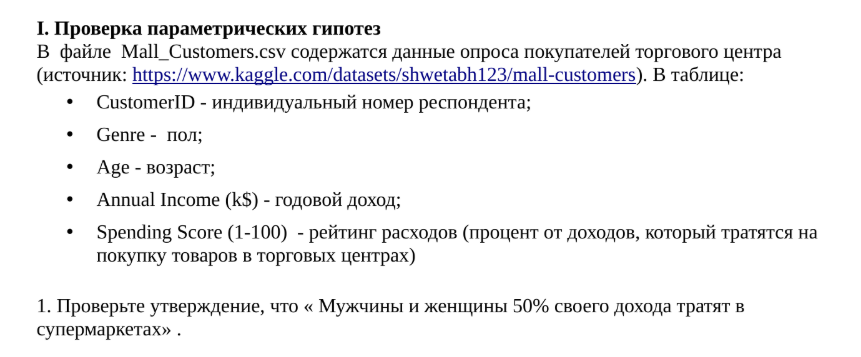

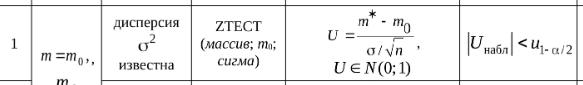

'Mean: 50.2, Std: 25.7588819633151, len: 200'

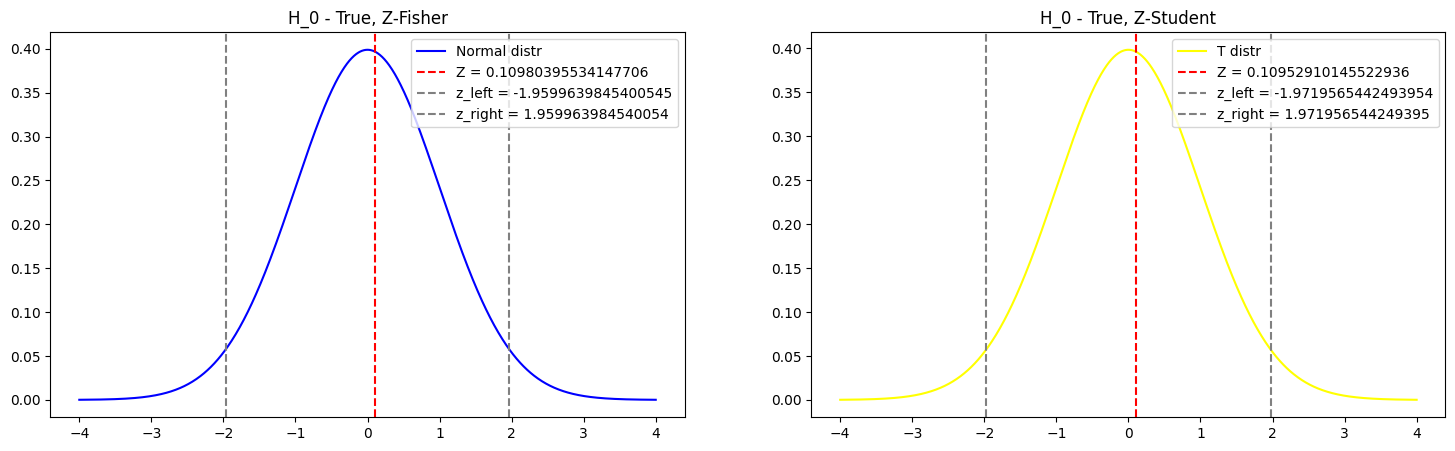

In [34]:
import numpy as np
import pandas as pd
from math import sqrt
from scipy import stats
import matplotlib.pyplot as plt


mall_df = pd.read_csv("Mall_Customers.csv", sep=",")
mall_df.columns = mall_df.columns.str.strip()
mall_df = mall_df.drop("CustomerID", axis=1)
# display(mall_df)

# H_0 = mu: 50%
# H_1 = mu: !50%
alpha = 0.05
m_0 = 50

mall_mean = mall_df["Spending Score (1-100)"].mean()
mall_std = mall_df["Spending Score (1-100)"].std(ddof=0)
mall_n = mall_df["Spending Score (1-100)"].count()

display(f"Mean: {mall_mean}, Std: {mall_std}, len: {mall_n}")

Z_fisher = (mall_mean - m_0) / (mall_std / sqrt(mall_n))
z_left = stats.norm.ppf(alpha / 2)
z_right = stats.norm.ppf(1 - alpha / 2)
res_fisher = z_left < Z_fisher < z_right

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1) 


fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].set_title(f"H_0 - {res_fisher}, Z-Fisher")
axes[0].plot(x, y, label="Normal distr", color="blue")
axes[0].axvline(Z_fisher, color="red", linestyle="--", label=f"Z = {Z_fisher}")
axes[0].axvline(z_left, color="grey", linestyle="--", label=f"z_left = {z_left}")
axes[0].axvline(z_right, color="grey", linestyle="--", label=f"z_right = {z_right}")
axes[0].legend()


mall_std = mall_df["Spending Score (1-100)"].std(ddof=1)

t_df = mall_n - 1
Z_student = (mall_mean - m_0) / (mall_std / sqrt(mall_n))
z_left = stats.t.ppf(alpha / 2, df=t_df)
z_right = stats.t.ppf(1 - alpha / 2, df=t_df)
res_student = z_left < Z_student < z_right

x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=t_df)
axes[1].set_title(f"H_0 - {res_student}, Z-Student")
axes[1].plot(x, y, label="T distr", color="yellow")
axes[1].axvline(Z_student, color="red", linestyle="--", label=f"Z = {Z_student}")
axes[1].axvline(z_left, color="grey", linestyle="--", label=f"z_left = {z_left}")
axes[1].axvline(z_right, color="grey", linestyle="--", label=f"z_right = {z_right}")
axes[1].legend()

plt.legend()
plt.show()